# 08 · Embeddings y búsqueda semántica de quejas (T-14, bloque K)

**Dónde:** `pipeline/src/nlp/similitud.py`. **Por qué:** cuando llega una queja nueva, el área de atención quiere
ver quejas parecidas ya atendidas (reutilizar la respuesta o detectar un brote en una zona).
**Cómo:** se comparan tres representaciones con la MISMA división por texto único del clasificador (un texto
nunca se encuentra a sí mismo): TF-IDF (coincidencia de palabras), LSA (SVD truncado de TF-IDF, densa) y,
si hay acceso a Hugging Face, Sentence-Transformers multilingüe. **Métrica:** precision@5 (de las 5 quejas más
parecidas, qué fracción es de la misma categoría). **Datos:** `data/simulados/quejas.csv` (simulación declarada).

In [1]:
import sys, pathlib
raiz = pathlib.Path.cwd()
while not (raiz / "pipeline").exists() and raiz != raiz.parent:
    raiz = raiz.parent
sys.path.insert(0, str(raiz))
import warnings; warnings.filterwarnings("ignore")
import pandas as pd
pd.set_option("display.max_colwidth", 120)
from pipeline.notebooks.graficas import dibujar, tabla

In [2]:
from pipeline.src.nlp.similitud import comparar
filas = comparar()          # intenta Sentence-Transformers; si no hay red lo reporta sin inventar
pd.DataFrame(filas)

,representacion,dimension,ejecutado,precision_at_5,motivo
0,TF-IDF,166.0,True,0.894,NaN
1,"LSA (SVD de TF-IDF, 100 dims)",100.0,True,0.894,NaN
2,Sentence-Transformers (paraphrase-multilingual-MiniLM-L12-v2),NaN,False,NaN,ModuleNotFoundError: No module named 'sentence_transformers'


## Resultado publicado (embeddings/similitud_precision5)

El mismo cálculo que corre `pipeline/src/nlp/resultados.py` y que se ve en la página **Quejas** de la app.

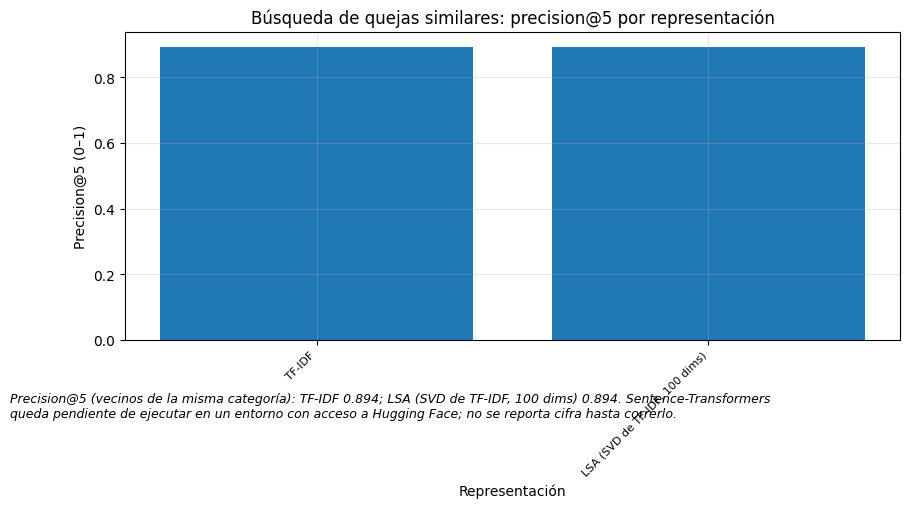

In [3]:
from pipeline.src.nlp.resultados import construir_payloads
piezas = {p["clave"]: p["payload"] for p in construir_payloads()}
dibujar(piezas["similitud_precision5"])

## Frente a TF-IDF

TF-IDF solo encuentra quejas que comparten palabras; una representación densa puede acercar sinónimos
("no llega agua" / "sin servicio"). La comparación se hace con la misma métrica y los mismos textos.

In [4]:
ejecutadas = [f for f in filas if f.get("ejecutado")]
mejor = max(ejecutadas, key=lambda f: f["precision_at_5"])
no_ejecutadas = [f for f in filas if not f.get("ejecutado")]
print(f"Mejor representación: {mejor['representacion']} (precision@5 = {mejor['precision_at_5']:.3f}).")
for f in ejecutadas:
    print(f"- {f['representacion']}: {f['precision_at_5']:.3f} con {f['dimension']} dimensiones")
for f in no_ejecutadas:
    print(f"- {f['representacion']}: NO ejecutado ({f.get('motivo', 'sin motivo')})")

Mejor representación: TF-IDF (precision@5 = 0.894).
- TF-IDF: 0.894 con 166 dimensiones
- LSA (SVD de TF-IDF, 100 dims): 0.894 con 100 dimensiones
- Sentence-Transformers (paraphrase-multilingual-MiniLM-L12-v2): NO ejecutado (ModuleNotFoundError: No module named 'sentence_transformers')


## Conclusiones

In [5]:
tfidf = next(f for f in filas if f["representacion"] == "TF-IDF")
top = max(f["precision_at_5"] for f in ejecutadas)
empatadas = [f["representacion"] for f in ejecutadas if abs(f["precision_at_5"] - top) < 5e-4]
if len(empatadas) > 1:
    print(f"1. Con división por texto único, {' y '.join(empatadas)} empatan en precision@5 = {top:.3f}: la representación densa (LSA) no mejora a TF-IDF en quejas cortas con vocabulario repetitivo.")
else:
    otras = ", ".join(f"{f['representacion']} {f['precision_at_5']:.3f}" for f in ejecutadas if f is not mejor)
    print(f"1. Con división por texto único, la mejor representación es {mejor['representacion']} (precision@5 = {mejor['precision_at_5']:.3f}) frente a {otras}.")
print("2. La métrica mide si las quejas parecidas son de la misma categoría: sirve para sugerir respuestas y detectar brotes, no para decidir la prioridad.")
print("3. " + ("Sentence-Transformers no se pudo ejecutar en este entorno; se reporta como pendiente y no se inventa su resultado." if no_ejecutadas else "Sentence-Transformers se ejecutó con el mismo protocolo."))
print("4. Los embeddings de Gemini (768 dimensiones) se usan en el RAG (notebook 09), no en esta comparación.")

1. Con división por texto único, TF-IDF y LSA (SVD de TF-IDF, 100 dims) empatan en precision@5 = 0.894: la representación densa (LSA) no mejora a TF-IDF en quejas cortas con vocabulario repetitivo.
2. La métrica mide si las quejas parecidas son de la misma categoría: sirve para sugerir respuestas y detectar brotes, no para decidir la prioridad.
3. Sentence-Transformers no se pudo ejecutar en este entorno; se reporta como pendiente y no se inventa su resultado.
4. Los embeddings de Gemini (768 dimensiones) se usan en el RAG (notebook 09), no en esta comparación.
